In [1]:
!pip install -q kaggle 

In [8]:
!mkdir kaggle 

In [9]:
!touch kaggle/kaggle.json

In [15]:
api_token = {"username":"zhouzack","key":"af3a9c3c27774937090d9cb942e9e9fb"}

In [16]:
import json 

with open('kaggle/kaggle.json','w') as file:
    json.dump(api_token,file)

In [13]:
!chmod 600 kaggle/kaggle.json

In [17]:
cat kaggle/kaggle.json

{"username": "zhouzack", "key": "af3a9c3c27774937090d9cb942e9e9fb"}

In [18]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --force

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100%|█████████████████████████████████████▉| 2.29G/2.29G [02:07<00:00, 17.5MB/s]
100%|██████████████████████████████████████| 2.29G/2.29G [02:07<00:00, 19.3MB/s]


In [19]:
import zipfile
with zipfile.ZipFile('./chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [22]:
import glob
import random
import matplotlib.pyplot as plt



def get_random_image(dir,condition):
    placeholder=''
    if condition == 'n':
        placeholder='NORMAL'
    elif condition == 'p':
        placeholder='PNEUMONIA'
    else:
        raise Exception("Sorry, invalid condition")
    folder=f'data/chest_xray/{dir}/{placeholder}/*.jpeg'
    img_paths=glob.glob(folder)
    max_length=len(img_paths)
    randomNumber=random.randint(0,max_length)
    for index, item in enumerate(img_paths, start=1):
        if index == randomNumber:
            print(index,item)
            image = plt.imread(item)
            readyImage=plt.imshow(image)
            return readyImage



4 data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg


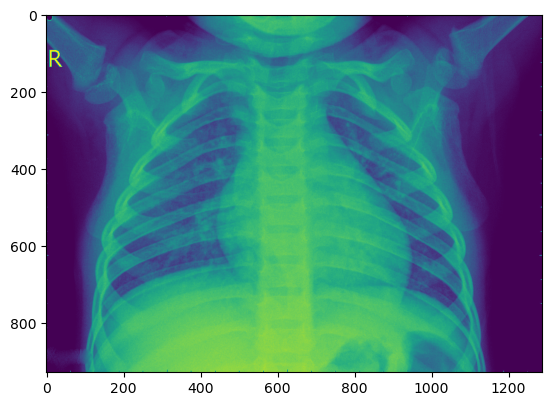

In [23]:
get_random_image("val","n")

In [25]:
from PIL import Image


image = Image.open('data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')  
print(image.format)
print(image.size)
print(image.mode)

JPEG
(1288, 928)
L


In [26]:
import PIL.Image

rgba_image=PIL.Image.open('data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')
rgb_image=rgba_image.convert('RGB')

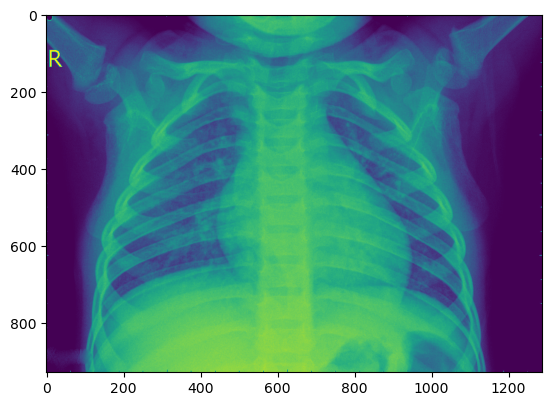

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')
imgplot = plt.imshow(img)
plt.show()

In [29]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'data/chest_xray/train/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/train' + '/train_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/train' + '/train_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1
        

In [30]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'./data/chest_xray/test/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/test' + '/test_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/test' + '/test_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1
        

In [31]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'./data/chest_xray/val/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/val' + '/val_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/val' + '/val_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1
        

In [32]:
import glob
import pandas as pd

folder=f'./data/chest_xray/*/*.jpeg'

category=[]
filenames=[]
condition_of_lung=[]

all_files=glob.glob(folder)

for filename in all_files:
    if "train" in filename:
        if "pneumonia" in filename:
            category.append("train")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("train")
            filenames.append(filename)
            condition_of_lung.append("normal")
    elif "test" in filename:
        if "pneumonia" in filename:
            category.append("test")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("test")
            filenames.append(filename)
            condition_of_lung.append("normal")
    elif "val" in filename:
        if "pneumonia" in filename:
            category.append("val")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("val")
            filenames.append(filename)
            condition_of_lung.append("normal")

all_data_df=pd.DataFrame({"dataset type":category,"x-ray result":condition_of_lung,"filename":filenames})

print(all_data_df.head())
            
        
        
    

  dataset type x-ray result                                  filename
0         test       normal  ./data/chest_xray/test/test_normal0.jpeg
1         test       normal  ./data/chest_xray/test/test_normal1.jpeg
2         test       normal  ./data/chest_xray/test/test_normal2.jpeg
3         test       normal  ./data/chest_xray/test/test_normal3.jpeg
4         test       normal  ./data/chest_xray/test/test_normal4.jpeg


In [34]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_119/1507534060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.catplot(x="x-ray result",col="dataset type",kind="count",palette="ch:.55",data=all_data_df,legend=True)


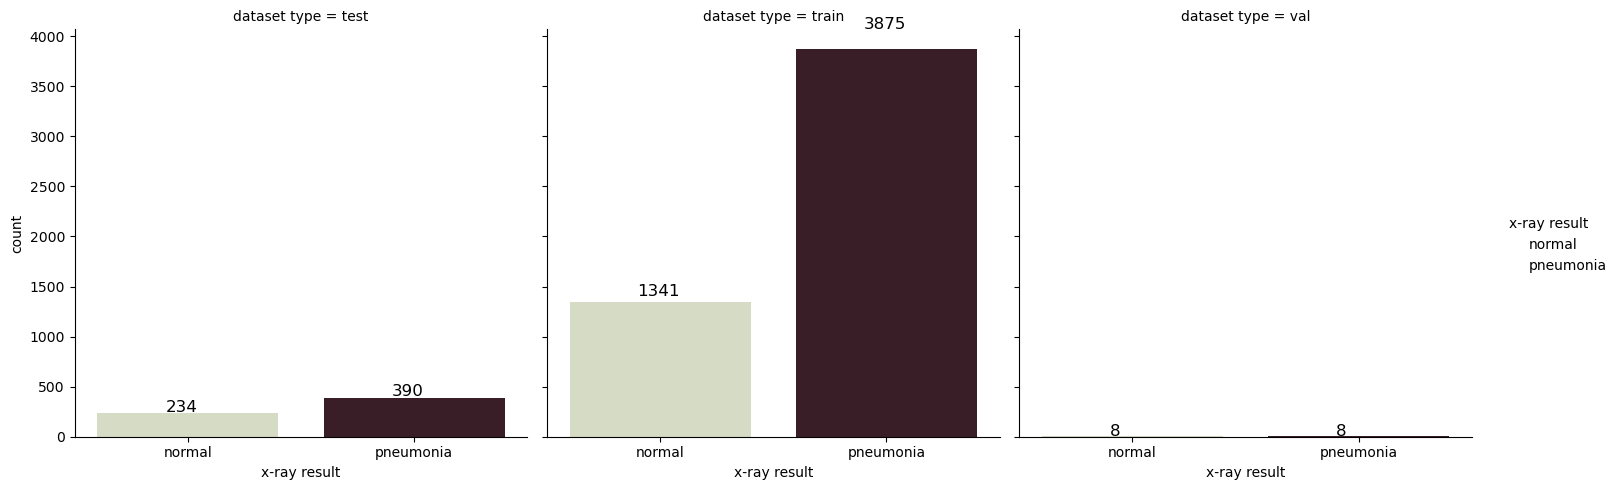

In [35]:
import seaborn as sns

g=sns.catplot(x="x-ray result",col="dataset type",kind="count",palette="ch:.55",data=all_data_df,legend=True)

for i in range(0,3):
    ax=g.facet_axis(0,i)
    for p in ax.patches:
        ax.text(p.get_x()+0.3,
        p.get_height()*1.05,
        '{0:.0f}'.format(p.get_height()),
        color='black',
        rotation='horizontal',
        size='large')



In [36]:
import glob
import pandas as pd
import os
train_folder='./data/chest_xray/train/*.jpeg'
train_df_lst=pd.DataFrame(columns=['labels','s3_path'],dtype=object)
train_imgs_path=glob.glob(train_folder)
counter=0
class_arg=''

for i in train_imgs_path:
    if "pneumonia" in i:
        class_arg=1
    else:
        class_arg=0
    train_df_lst.loc[counter]=[class_arg,os.path.basename(i)]
    counter+=1
print(train_df_lst.head())

   labels             s3_path
0       0  train_normal0.jpeg
1       0  train_normal1.jpeg
2       0  train_normal2.jpeg
3       0  train_normal3.jpeg
4       0  train_normal4.jpeg


In [37]:
import glob
import pandas as pd
import os
test_folder='./data/chest_xray/test/*.jpeg'
test_df_lst=pd.DataFrame(columns=['labels','s3_path'],dtype=object)
test_imgs_path=glob.glob(test_folder)
counter=0
class_arg=''

for i in test_imgs_path:
    if "pneumonia" in i:
        class_arg=1
    else:
        class_arg=0
    test_df_lst.loc[counter]=[class_arg,os.path.basename(i)]
    counter+=1
print(test_df_lst.head())

   labels            s3_path
0       0  test_normal0.jpeg
1       0  test_normal1.jpeg
2       0  test_normal2.jpeg
3       0  test_normal3.jpeg
4       0  test_normal4.jpeg


In [38]:
def save_to_lst(df,prefix):
    return df[["labels","s3_path"]].to_csv(
    f"{prefix}.lst", sep='\t',index=True,header=False
    )

save_to_lst(train_df_lst.copy(),"train")
save_to_lst(test_df_lst.copy(),"test")

In [39]:
bucket='sagemaker-bucket-851725491342'
print("bucket:{}".format(bucket))
region='ap-southeast-2'
print("region:{}".format(region))
roleArn='arn:aws:s3:::sagemaker-bucket-851725491342'
print("roleArn:{}".format(roleArn))


bucket:sagemaker-bucket-851725491342
region:ap-southeast-2
roleArn:arn:aws:s3:::sagemaker-bucket-851725491342


In [40]:
import os

os.environ["DEFAULT_S3_BUCKET"]=bucket


In [41]:
!aws s3 sync ./data/chest_xray/train s3://${DEFAULT_S3_BUCKET}/train/

upload: data/chest_xray/train/NORMAL/IM-0117-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0117-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0119-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0119-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0127-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0127-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0125-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0125-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0128-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0128-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0122-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0122-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0115-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0115-0001.jpeg
upload: data/chest_xray/train/NORMAL/IM-0137-0001.jpeg to s3://sagemaker-bucket-851725491342/train/NORMAL/IM-0137-0001.jpeg
upload: 

In [42]:
!aws s3 sync ./data/chest_xray/test s3://${DEFAULT_S3_BUCKET}/test/

upload: data/chest_xray/test/NORMAL/IM-0001-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0001-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0003-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0003-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0006-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0006-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0009-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0009-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0005-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0005-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0007-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0007-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0015-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0015-0001.jpeg
upload: data/chest_xray/test/NORMAL/IM-0010-0001.jpeg to s3://sagemaker-bucket-851725491342/test/NORMAL/IM-0010-0001.jpeg
upload: data/chest_xray/

In [43]:
import boto3

boto3.Session().resource('s3').Bucket(bucket).Object("train.lst").upload_file('./train.lst')

In [44]:
boto3.Session().resource('s3').Bucket(bucket).Object("test.lst").upload_file('./test.lst')

In [110]:
bucket='sagemaker-bucket-851725491342'
print("bucket:{}".format(bucket))
region='ap-southeast-2'
print("region:{}".format(region))
roleArn='arn:aws:s3:::sagemaker-bucket-851725491342'
print("roleArn:{}".format(roleArn))


bucket:sagemaker-bucket-851725491342
region:ap-southeast-2
roleArn:arn:aws:s3:::sagemaker-bucket-851725491342


In [111]:
import sagemaker
from sagemaker import image_uris
import boto3
from sagemaker import get_execution_role
sess=sagemaker.Session()

algorithm_image=image_uris.retrieve(
    region=boto3.Session().region_name,
    framework="image-classification",
    version="latest"
)

s3_output_location=f"s3://{bucket}/models/image_model"
print(algorithm_image)

Defaulting to the only supported framework/algorithm version: 1. Ignoring framework/algorithm version: latest.


544295431143.dkr.ecr.ap-southeast-2.amazonaws.com/image-classification:1


In [112]:
role=get_execution_role()
print(role)

arn:aws:iam::851725491342:role/service-role/AmazonSageMaker-ExecutionRole-20250126T121089


In [118]:
import sagemaker
img_classifier_model=sagemaker.estimator.Estimator(
    algorithm_image,
    role=role,
    instance_count=1,
    instance_type="ml.g4dn.xlarge",
    use_spot_instances=True,  # Enable spot instances
    max_run=432000,           # 5 days (432,000 seconds)
    max_wait=432000,          # Must be >= max_run
    volume_size=50,
    input_mode="File",
    output_path=s3_output_location,
    sagemaker_session=sess
)
print(img_classifier_model)

In [119]:
import glob 
count=0

for filepath in glob.glob('./data/chest_xray/train/*.jpeg'):
    count+=1
print(count)

5216


In [120]:
count = 5216  # Example: Total training images
img_classifier_model.set_hyperparameters(
    image_shape='3,224,224',
    num_classes='2',  # As string
    use_pretrained_model='1',  # As string
    num_training_samples=str(count),  # As string
    augmentation_type='crop_color_transform',
    epochs='15',  # As string
    early_stopping='True',  # As string
    early_stopping_min_epochs='8',
    early_stopping_tolerance='0.0',
    early_stopping_patience='5',
    lr_scheduler_factor='0.1',
    lr_scheduler_step='8,10,12'
)

In [121]:
from sagemaker.tuner import CategoricalParameter,ContinuousParameter,HyperparameterTuner

hyperparameter_ranges={
    "learning_rate":ContinuousParameter(0.01,0.1),
    "mini_batch_size":CategoricalParameter([8,16,32]),
    "optimizer":CategoricalParameter(["sgd","adam"])
}

In [122]:
objective_metric_name="validation:accuracy"
objective_type="Maximize"
max_jobs=5
max_parallel_jobs=1

In [123]:
tuner=HyperparameterTuner(estimator=img_classifier_model,
                         objective_metric_name=objective_metric_name,
                         hyperparameter_ranges=hyperparameter_ranges,
                         objective_type=objective_type,
                         max_jobs=max_jobs,
                         max_parallel_jobs=max_parallel_jobs  
                         )

In [124]:
from sagemaker.session import TrainingInput

model_inputs={
    "train":sagemaker.inputs.TrainingInput(s3_data=f"s3://{bucket}/train/",content_type="application/x-image"),
    "validation":sagemaker.inputs.TrainingInput(s3_data=f"s3://{bucket}/test/",content_type="application/x-image"),
    "train_lst":sagemaker.inputs.TrainingInput(s3_data=f"s3://{bucket}/train.lst",content_type="application/x-image"),
    "validation_lst":sagemaker.inputs.TrainingInput(s3_data=f"s3://{bucket}/test.lst",content_type="application/x-image"),
}

In [125]:
import time 
job_name_prefix="classifier"
timestamp=time.strftime("-%Y-%m-%d-%H-%M-%S",time.gmtime())
job_name=job_name_prefix+timestamp

In [ ]:
tuner.fit(inputs=model_inputs,job_name=job_name,logs=True)

No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [ ]:
import sagemaker
from sagemaker import get_execution_role

In [ ]:
role=get_execution_role()

In [ ]:
model=sagemaker.model.Model(
image_uri=algorithm_image,
model_data='',
role=role)

In [ ]:
endpoint_name=''

deployment=model.deploy(
initial_instance_count=1,
instance_type='ml.m4.xlarge',
endpoint_name=endpoint_name)

In [ ]:
from sagemaker.predictor import Predictor
predictor=Predictor("")

In [ ]:
from sagemaker.serializers import IdentitySerializer
import base64

file_name='data/chest_xray/val/val_pneumonia0.jpeg'

predictor.serializer= IdentitySerializer("image/jpeg")
with open(file_name,"rb")as f:
    payload=f.read()
    
inference=predictor.predict(data=payload)
print(inference)


In [ ]:
print(inference[1])

In [ ]:
import glob
import json
import numpy as np
file_path='data/chest_xray/val/*.jpeg'
files=glob.glob(file_path)

y_true=[]
y_pred=[]

def make_pred():
    for file in files:
        if "normal" in file:
            with open(file,"rb") as f:
                payload=f.read()
                inference=predictor.predict(data=payload).decode("utf-8")
                result=json.loads(inference)
                predicted_class=np.argmax(result)
                y_true.append(0)
                y_pred.append(predicted_class)
        elif "pneumonia" in file:
            with open(file,"rb") as f:
                payload=f.read()
                inference=predictor.predict(data=payload).decode("utf-8")
                result=json.loads(inference)
                predicted_class=np.argmax(result)
                y_true.append(1)
                y_pred.append(predicted_class)

make_pred()
print(y_true)
print(y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true,y_pred)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))